In [1]:
import torch
from kan import KAN as PyKAN
from kan.utils import create_dataset, add_symbolic, ex_round
from matplotlib import pyplot as plt
from scipy import special
from torch import nn, optim
from tqdm import tqdm

from efficient_kan.kan import KAN as EffKAN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 特殊函数实验（正弦积分）

本实验关注正弦积分函数：

$$Si(x) = \int_0^x \frac{\sin(t)}{t}\, dt$$

该函数不能由常见初等函数的有限复合表示，因此属于特殊函数。和多数符号回归算法相比，PyKAN 仍可给出有效近似，不过精度受网络深度影响较大。
考虑到可解释性，这里采用相对小型的网络结构。

## 数据集与可视化

In [2]:
steps = 1000

def sine_integral(x):
    x_np = x.detach().cpu().view(-1).numpy()
    si_vals = special.sici(x_np)[0]
    return torch.from_numpy(si_vals).to(dtype=torch.float32).view(-1, 1)

dataset = create_dataset(
    sine_integral,
    n_var=1,
    ranges=[-20, 20],
    train_num=5000,
    normalize_label=True,
    normalize_input=True,
)

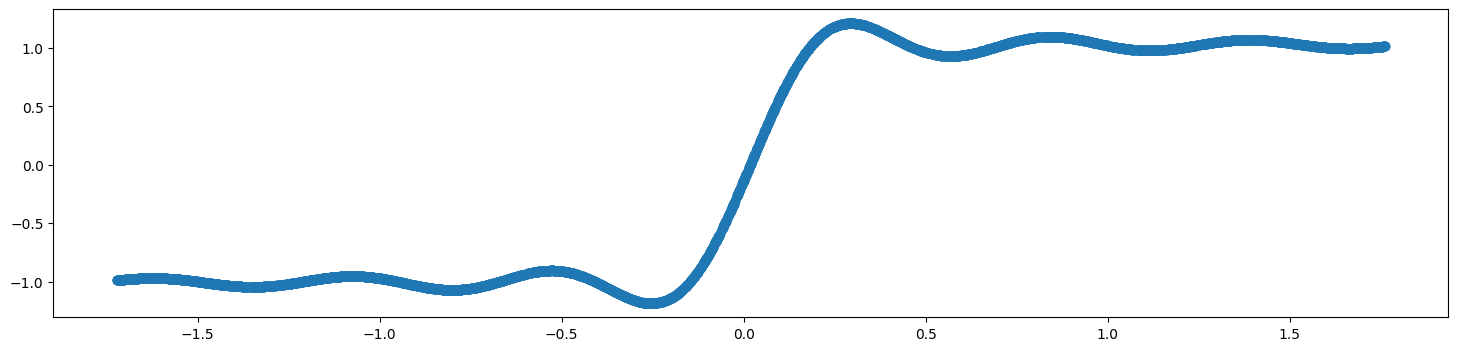

In [3]:
fig, ax = plt.subplots()
ax.scatter(dataset["train_input"].to('cpu'), dataset["train_label"].to('cpu'))
fig.set_size_inches(18, 4)
plt.show()

## PyKAN 训练

In [4]:
model = PyKAN(width=[1, 2, 1, 1], grid=5, k=3)
model.fit(dataset, opt="LBFGS", steps=40, lamb=0.01, lamb_entropy=4.0)


# Save pre-symbolic parameters for fair comparison
model_pre_symbolic_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.94e-02 | test_loss: 3.94e-02 | reg: 1.06e+01 | : 100%|█| 40/40 [00:20<00:00,  1.95it

saving model version 0.1


### PyKAN 学到了什么？
向模型输入等间距采样点，观察其对目标函数的近似形态。

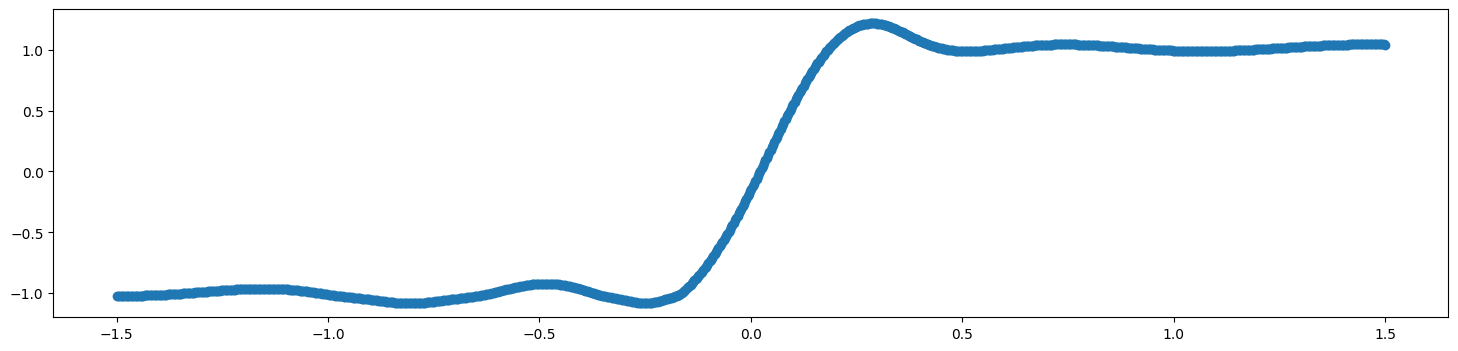

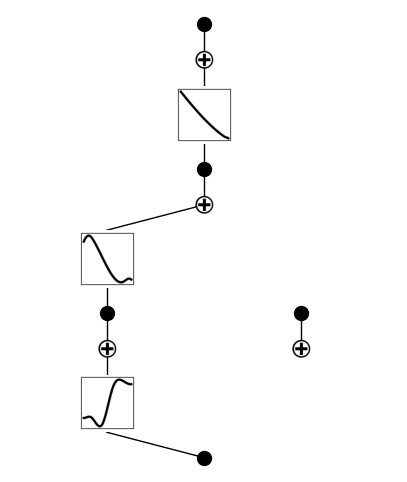

In [5]:
x_axis_kan = torch.linspace(-1.5, 1.5, steps=steps)
y_axis_kan = model(x_axis_kan.view(-1, 1)).detach().numpy()
fig, ax = plt.subplots()
ax.scatter(x_axis_kan, y_axis_kan)
fig.set_size_inches(18, 4)
plt.show()
model.plot(scale=.5)

In [6]:
add_symbolic('sinx', lambda x:torch.sin(x).mul_(x))

In [7]:
model.suggest_symbolic(0,0,0)
model.suggest_symbolic(1,0,0)
model.suggest_symbolic(2,0,0)



  function  fitting r2   r2 loss  complexity  complexity loss  total loss
0     sinx    0.961900 -4.713702           1                1   -0.142740
1        0    0.000000  0.000014           0                0    0.000003
2        x    0.762535 -2.074155           1                1    0.385169
3      cos    0.957233 -4.547017           2                2    0.690597
4      sin    0.957233 -4.547017           2                2    0.690597
  function  fitting r2   r2 loss  complexity  complexity loss  total loss
0     sinx    0.950921 -4.348444           1                1   -0.069689
1        x    0.939806 -4.054005           1                1   -0.010801
2        0    0.000000  0.000014           0                0    0.000003
3      cos    0.946671 -4.228667           2                2    0.754267
4      sin    0.946670 -4.228651           2                2    0.754270
  function  fitting r2    r2 loss  complexity  complexity loss  total loss
0     sinx    0.999963 -14.383870    

('sinx',
 (<function __main__.<lambda>(x)>, sinx, 1, <function __main__.<lambda>(x)>),
 0.9999632239341736,
 1)

r2 is 0.9619004130363464
saving model version 0.2
Best value at boundary.
r2 is 0.950920581817627
saving model version 0.3
r2 is 0.9999632239341736
saving model version 0.4


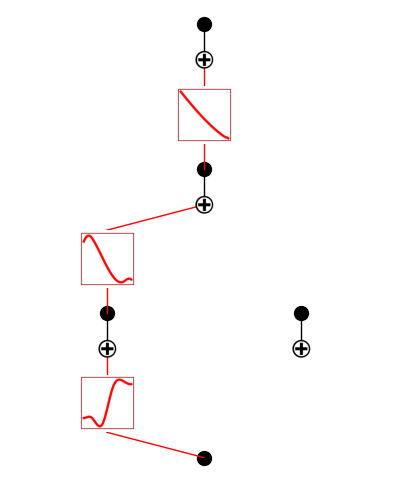

In [8]:
model.fix_symbolic(0, 0, 0, 'sinx')
model.fix_symbolic(1, 0, 0, 'sinx')
model.fix_symbolic(2, 0, 0, 'sinx')
model.plot()
pass

In [9]:
model.fit(dataset, opt="LBFGS", steps=40)
pass

| train_loss: 3.86e-02 | test_loss: 3.80e-02 | reg: 3.34e+00 | : 100%|█| 40/40 [00:29<00:00,  1.36it

saving model version 0.5


In [10]:
formula = model.symbolic_formula()[0][0]
ex_round(formula, 3)

2.269 - 1.844*sinx(0.834*sinx(0.147*sinx(-1.189*x_1 - 9.766) - 0.617) - 2.365)

# EfficientKAN
进一步验证 EfficientKAN 在该任务上同样能达到较高精度。

In [11]:
class Efficient_KAN(nn.Module):
    def __init__(self, grid_size=200):
        super(Efficient_KAN, self).__init__()
        self.layers = [1, 2, 1, 1]
        self.model = EffKAN(self.layers,
                            grid_size=grid_size,
                            # grid_eps=1,
                            # scale_base=0,
                            # sp_trainable=False,
                            # sb_trainable=False,
                            # enable_standalone_scale_spline=False
                            ).to(device)
        self.double()

    def forward(self, x):
        # x = x / dataset_size * 2 - 1
        # x = x.view(-1, self.layers[0])
        x = self.model(x)
        return x

In [12]:
def train(model, optimizer, inputs: torch.Tensor, labels, epochs=5, batch_size=200):
    criterion = nn.MSELoss()
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)
    flat_labels = labels.view(-1).double()
    for epoch in range(epochs):
        model.train()
        with tqdm(range(inputs.size(0) // batch_size)) as pbar:
            for i in pbar:
                x = inputs[i * batch_size:(i + 1) * batch_size].to(device)
                y = flat_labels[i * batch_size:(i + 1) * batch_size].to(device)
                optimizer.zero_grad()
                output = model(x).view(-1)
                loss = criterion(output, y)
                loss.backward()
                optimizer.step()
                pbar.set_postfix(loss=loss.item(), lr=optimizer.param_groups[0]['lr'])
                scheduler.step()

In [13]:
model2 = Efficient_KAN(grid_size=5)
train(model2, optim.Adam(model2.parameters(), lr=0.03), dataset["train_input"], dataset["train_label"], epochs=150,
      batch_size=100)

100%|██████████| 50/50 [00:00<00:00, 270.03it/s, loss=5.17e-5, lr=1.65e-5]


In [14]:
print('train_input_range =', float(dataset['train_input'].min()), float(dataset['train_input'].max()))
print('test_input_range =', float(dataset['test_input'].min()), float(dataset['test_input'].max()))

with torch.no_grad():
    pred = model2(dataset['test_input'].to(device)).cpu().view(-1)
    target = dataset['test_label'].cpu().view(-1).double()
    mse = torch.mean((pred - target) ** 2).item()
print('efficient_test_mse =', mse)

train_input_range = -1.7221468687057495 1.7617435455322266
test_input_range = -1.7153266668319702 1.7602686882019043
efficient_test_mse = 4.035906149643213e-05


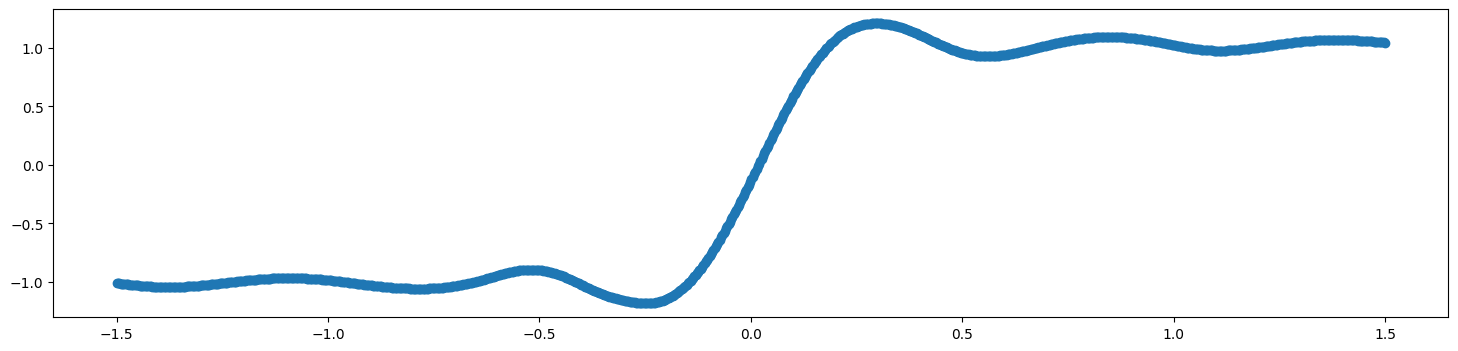

In [15]:
x_axis = torch.linspace(-1.5, 1.5, steps=steps, dtype=torch.float64, device=device)
with torch.no_grad():
    y_axis = model2(x_axis.view(-1, 1)).detach().cpu().view(-1).numpy()

fig, ax = plt.subplots()
ax.scatter(x_axis.cpu().numpy(), y_axis)
fig.set_size_inches(18, 4)
plt.show()

## 更复杂的 KAN 结构

In [16]:
model3 = PyKAN(width=[1, 2, 5, 1], grid=5, k=3)
model3.fit(dataset, opt="adam", steps=10, lamb=0.01, lamb_entropy=4.0)
model3.fit(dataset, opt="LBFGS", steps=50)

# Save pre-symbolic parameters for fair comparison
model3_pre_symbolic_state = {k: v.detach().clone() for k, v in model3.state_dict().items()}

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.86e-02 | test_loss: 9.55e-01 | reg: 3.34e+00 | : 100%|█| 10/10 [00:00<00:00, 31.44it


saving model version 0.1


| train_loss: 3.93e-03 | test_loss: 4.01e-03 | reg: 1.91e+01 | : 100%|█| 50/50 [00:43<00:00,  1.15it

saving model version 0.2


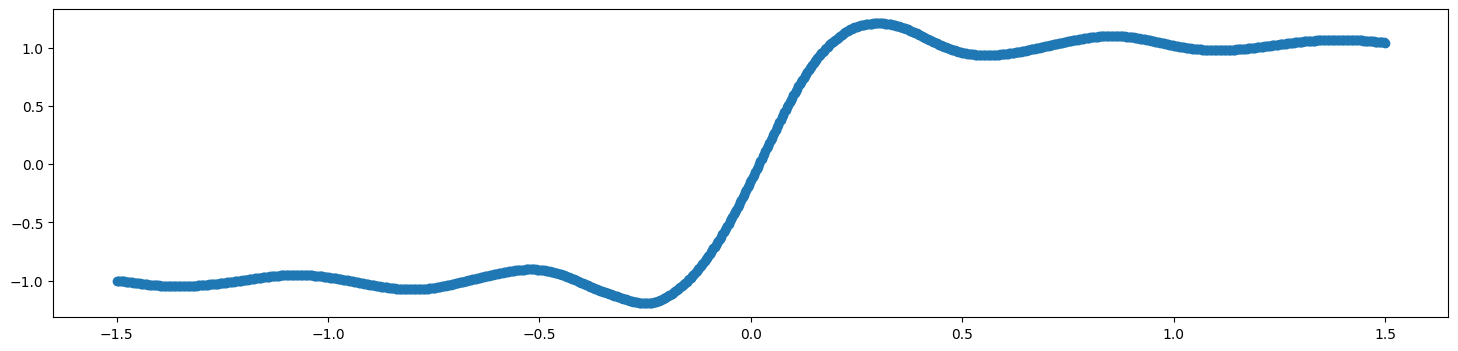

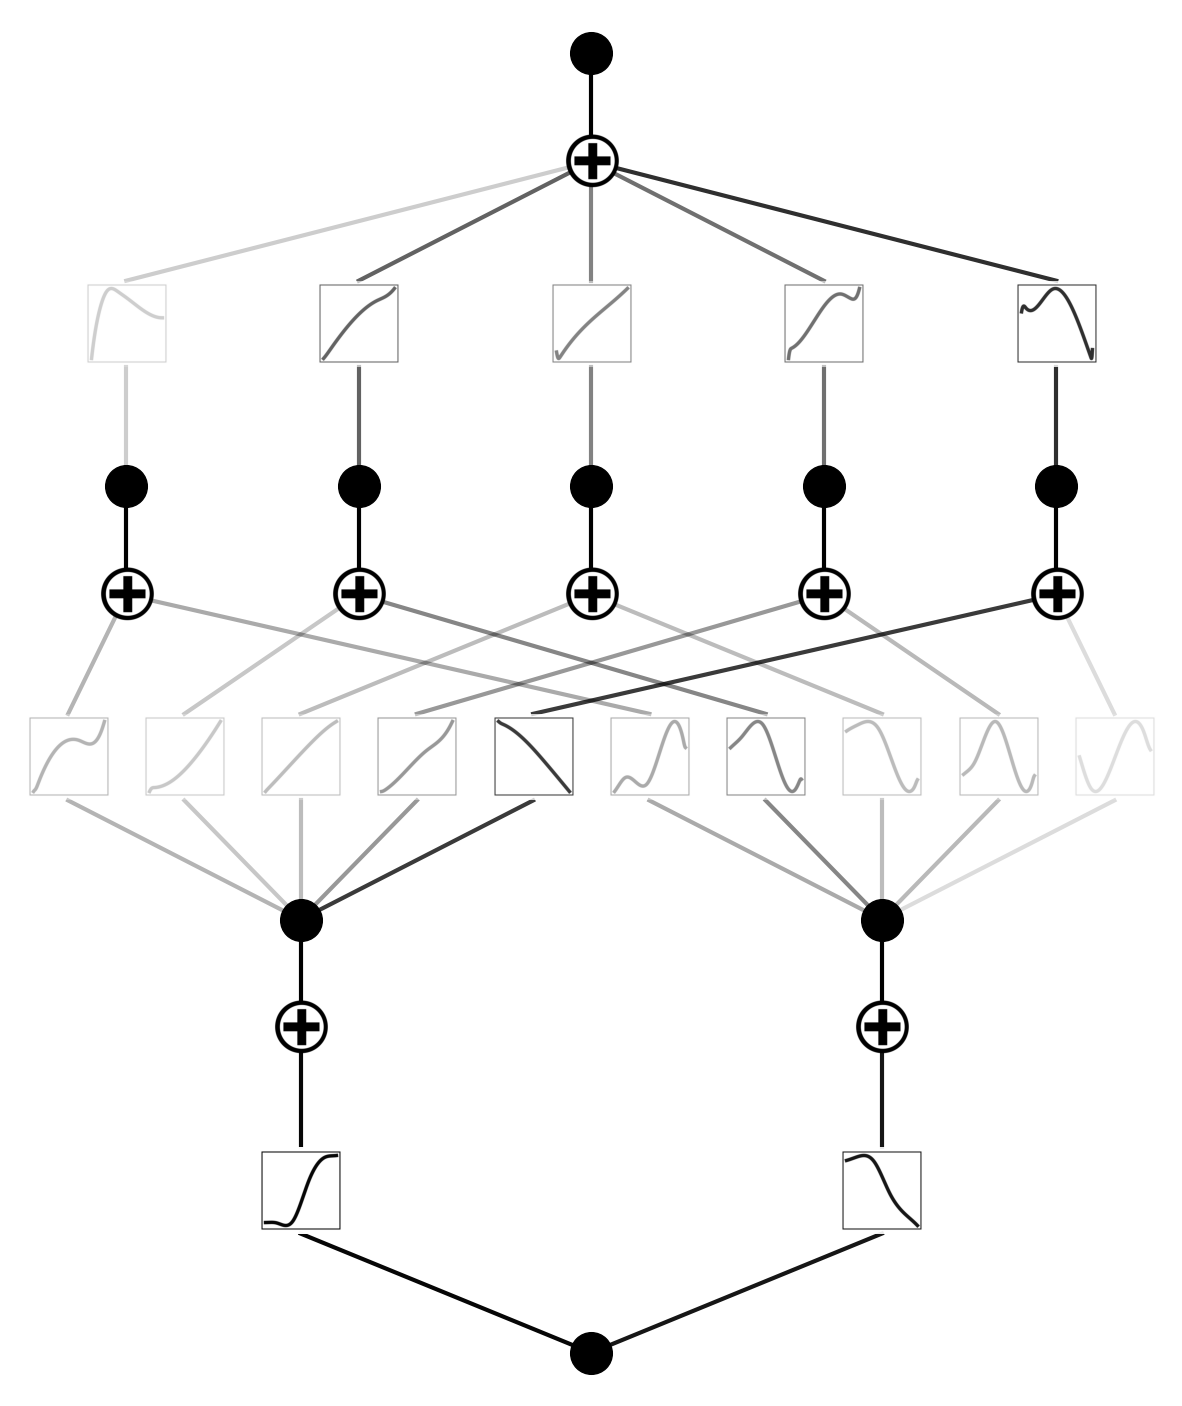

In [17]:
x_axis_com_kan = torch.linspace(-1.5, 1.5, steps=steps)
y_axis_com_kan = model3(x_axis_com_kan.view(-1, 1)).detach().numpy()
fig, ax = plt.subplots()
ax.scatter(x_axis_com_kan, y_axis_com_kan)
fig.set_size_inches(18, 4)
plt.show()

model3.plot(scale=1.5)

In [18]:
#model3.prune()
model3.auto_symbolic()

fixing (0,0,0) with sinx, r2=0.9934331774711609, c=1
fixing (0,0,1) with sinx, r2=0.9959598779678345, c=1
fixing (1,0,0) with sinx, r2=0.9678322672843933, c=1
fixing (1,0,1) with sinx, r2=0.9992574453353882, c=1
fixing (1,0,2) with sinx, r2=0.9999832510948181, c=1
fixing (1,0,3) with sinx, r2=0.9981764554977417, c=1
fixing (1,0,4) with sinx, r2=0.9999516010284424, c=1
fixing (1,1,0) with sinx, r2=0.948142945766449, c=1
fixing (1,1,1) with sinx, r2=0.9963205456733704, c=1
fixing (1,1,2) with sinx, r2=0.9977672100067139, c=1
fixing (1,1,3) with sinx, r2=0.9969791769981384, c=1
fixing (1,1,4) with sinx, r2=0.9931853413581848, c=1
fixing (2,0,0) with 0, r2=0.0, c=0
fixing (2,1,0) with sinx, r2=0.9990324378013611, c=1
fixing (2,2,0) with sinx, r2=0.9968679547309875, c=1
fixing (2,3,0) with sinx, r2=0.9901809096336365, c=1
fixing (2,4,0) with sinx, r2=0.9883370399475098, c=1
saving model version 0.3


In [19]:
model3.fit(dataset, opt="LBFGS", steps=40)
pass

| train_loss: 1.06e-02 | test_loss: 1.04e-02 | reg: 0.00e+00 | : 100%|█| 40/40 [00:41<00:00,  1.03s/

saving model version 0.4


In [20]:
formula3 = model3.symbolic_formula()[0][0]
ex_round(formula3, 3)

0.217*sinx(-0.125*sinx(8.886 - 0.317*sinx(-1.374*x_1 - 9.548)) + 0.228*sinx(-0.178*sinx(-1.684*x_1 - 6.062) - 5.646) - 3.034) + 0.116*sinx(0.151*sinx(9.718 - 0.161*sinx(-1.684*x_1 - 6.062)) - 0.233*sinx(-0.254*sinx(-1.374*x_1 - 9.548) - 3.566) + 3.301) + 2.63*sinx(-0.008*sinx(-0.144*sinx(-1.684*x_1 - 6.062) - 5.296) + 0.015*sinx(-0.306*sinx(-1.374*x_1 - 9.548) - 3.353) + 7.941) + 0.209*sinx(-5.221*sinx(-0.053*sinx(-1.684*x_1 - 6.062) - 5.002) - 0.148*sinx(-0.39*sinx(-1.374*x_1 - 9.548) - 9.097) - 20.705) - 20.043

# 结果对比

本节对比三组结果：PyKAN、EfficientKAN 以及更复杂的 PyKAN。图中红线为真实函数，蓝线为模型学习结果。

checkpoint directory created: ./model
saving model version 0.0


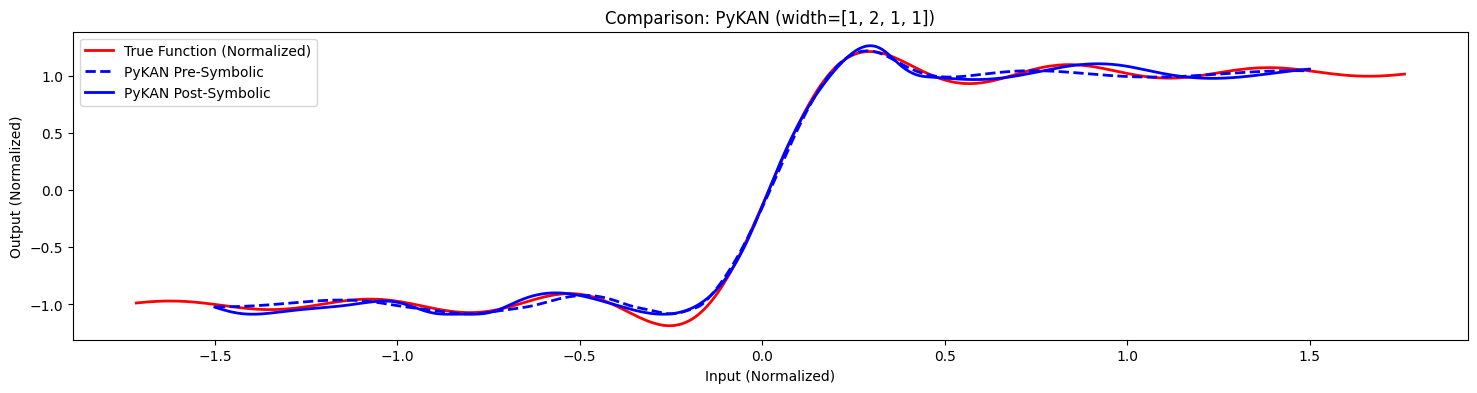

In [21]:
# 1. Base PyKAN model (model): compare pre/post symbolic on one plot
fig, ax = plt.subplots(figsize=(18, 4))

test_inputs = dataset['test_input']
test_labels = dataset['test_label'].view(-1)

# Plot the ground-truth curve with the same sorted test set
sort_idx = torch.argsort(test_inputs[:, 0])
x_axis_sorted = test_inputs[sort_idx, 0].cpu().numpy()
y_true_sorted = test_labels[sort_idx].cpu().numpy()

# Rebuild the pre-symbolic model
model_pre = PyKAN(width=[1, 2, 1, 1], grid=5, k=3)
model_pre.load_state_dict(model_pre_symbolic_state)

x_axis = torch.linspace(-1.5, 1.5, steps=steps)
with torch.no_grad():
    y_axis_pykan_pre = model_pre(x_axis.view(-1, 1)).detach().cpu().view(-1).numpy()
    y_axis_pykan_post = model(x_axis.view(-1, 1)).detach().cpu().view(-1).numpy()

ax.plot(x_axis_sorted, y_true_sorted, 'r-', label='True Function (Normalized)', linewidth=2)
ax.plot(x_axis.cpu().numpy(), y_axis_pykan_pre, 'b--', label='PyKAN Pre-Symbolic', linewidth=2)
ax.plot(x_axis.cpu().numpy(), y_axis_pykan_post, 'b-', label='PyKAN Post-Symbolic', linewidth=2)

ax.set_title("Comparison: PyKAN (width=[1, 2, 1, 1])")
ax.set_xlabel("Input (Normalized)")
ax.set_ylabel("Output (Normalized)")
ax.legend()
plt.show()

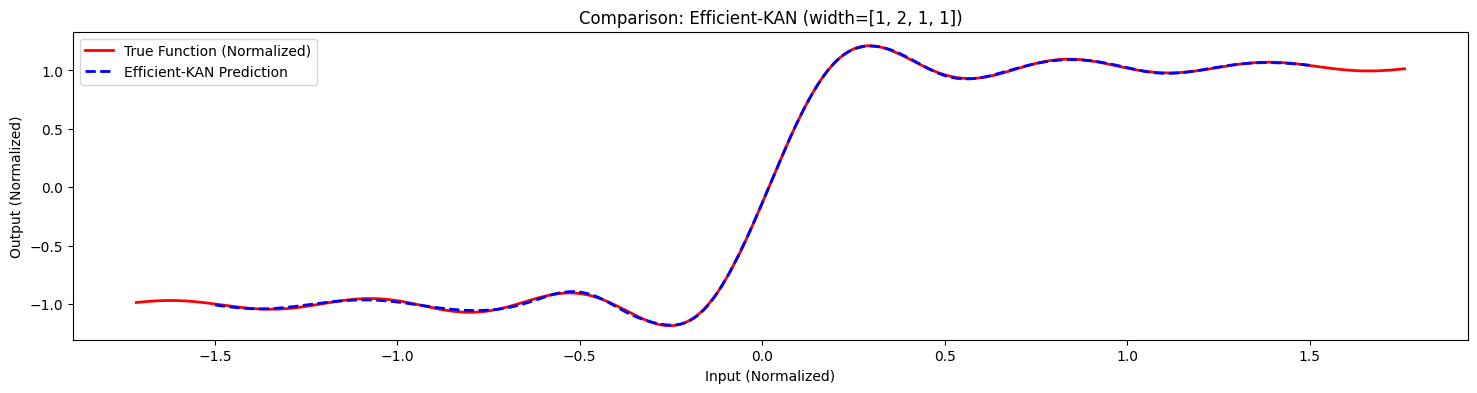

In [22]:
# 2. Efficient-KAN model (model2) comparison
# model2 is an Efficient_KAN instance wrapping EffKAN with double()
test_inputs = dataset['test_input']
test_labels = dataset['test_label']

with torch.no_grad():
    model_device = next(model2.parameters()).device
    model_dtype = next(model2.parameters()).dtype
    inputs_device = test_inputs.to(model_device).to(model_dtype)
    predictions = model2(inputs_device).cpu().view(-1).numpy()

sort_idx = torch.argsort(test_inputs[:, 0])
x_axis_sorted = test_inputs[sort_idx, 0].numpy()
y_true_sorted = test_labels.view(-1)[sort_idx].numpy()
y_pred_sorted = predictions[sort_idx.numpy()]

x_axis = torch.linspace(-1.5, 1.5, steps=steps, dtype=model_dtype, device=model_device)
with torch.no_grad():
    y_axis = model2(x_axis.view(-1, 1)).detach().cpu().view(-1).numpy()

fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(x_axis_sorted, y_true_sorted, 'r-', label='True Function (Normalized)', linewidth=2)
ax.plot(x_axis.cpu().numpy(), y_axis, 'b--', label='Efficient-KAN Prediction', linewidth=2)

ax.set_title("Comparison: Efficient-KAN (width=[1, 2, 1, 1])")
ax.set_xlabel("Input (Normalized)")
ax.set_ylabel("Output (Normalized)")
ax.legend()
plt.show()

checkpoint directory created: ./model
saving model version 0.0


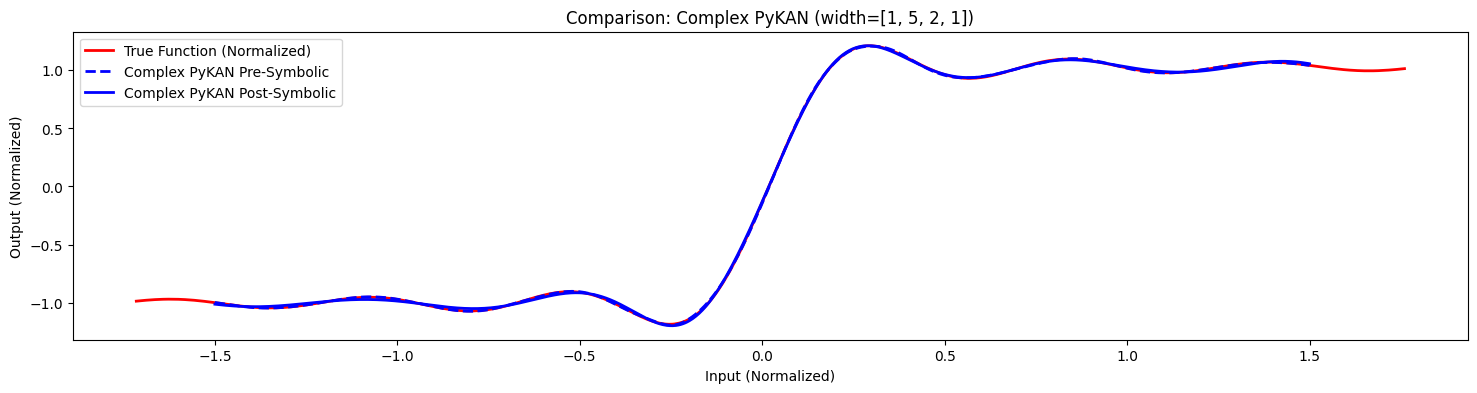

In [23]:
# 3. Complex PyKAN model (model3): compare pre/post symbolic on one plot
test_inputs = dataset['test_input']
test_labels = dataset['test_label'].view(-1)

# Use the same ground-truth plotting logic as Figure 1
sort_idx = torch.argsort(test_inputs[:, 0])
x_axis_sorted = test_inputs[sort_idx, 0].cpu().numpy()
y_true_sorted = test_labels[sort_idx].cpu().numpy()

# Rebuild the pre-symbolic complex model
model3_pre = PyKAN(width=[1, 2, 5, 1], grid=5, k=3)
model3_pre.load_state_dict(model3_pre_symbolic_state)

x_axis_com = torch.linspace(-1.5, 1.5, steps=steps)
with torch.no_grad():
    y_axis_complex_pre = model3_pre(x_axis_com.view(-1, 1)).detach().cpu().view(-1).numpy()
    y_axis_complex_post = model3(x_axis_com.view(-1, 1)).detach().cpu().view(-1).numpy()

fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(x_axis_sorted, y_true_sorted, 'r-', label='True Function (Normalized)', linewidth=2)
ax.plot(x_axis_com.cpu().numpy(), y_axis_complex_pre, 'b--', label='Complex PyKAN Pre-Symbolic', linewidth=2)
ax.plot(x_axis_com.cpu().numpy(), y_axis_complex_post, 'b-', label='Complex PyKAN Post-Symbolic', linewidth=2)

ax.set_title("Comparison: Complex PyKAN (width=[1, 5, 2, 1])")
ax.set_xlabel("Input (Normalized)")
ax.set_ylabel("Output (Normalized)")
ax.legend()
plt.show()

In [25]:
# Evaluate all three models on the same test set (clear pre/post symbolic split)
with torch.no_grad():
    x_test = dataset['test_input']
    y_test = dataset['test_label'].view(-1).double().cpu()

    # Base PyKAN: rebuilt pre-symbolic model + current post-symbolic model
    model_pre = PyKAN(width=[1, 2, 1, 1], grid=5, k=3)
    model_pre.load_state_dict(model_pre_symbolic_state)
    y_pykan_pre = model_pre(x_test).view(-1).double().cpu()
    y_pykan_post = model(x_test).view(-1).double().cpu()

    # Complex PyKAN: rebuilt pre-symbolic model + current post-symbolic model
    model3_pre = PyKAN(width=[1, 2, 5, 1], grid=5, k=3)
    model3_pre.load_state_dict(model3_pre_symbolic_state)
    y_pykan_complex_pre = model3_pre(x_test).view(-1).double().cpu()
    y_pykan_complex_post = model3(x_test).view(-1).double().cpu()

    # EfficientKAN has numeric model only (no pre/post symbolic split)
    model2_device = next(model2.parameters()).device
    model2_dtype = next(model2.parameters()).dtype
    x_test_eff = x_test.to(model2_device).to(model2_dtype)
    y_effkan = model2(x_test_eff).view(-1).double().cpu()

mse_pykan_pre = torch.mean((y_pykan_pre - y_test) ** 2).item()
mse_pykan_post = torch.mean((y_pykan_post - y_test) ** 2).item()
mse_effkan = torch.mean((y_effkan - y_test) ** 2).item()
mse_pykan_complex_pre = torch.mean((y_pykan_complex_pre - y_test) ** 2).item()
mse_pykan_complex_post = torch.mean((y_pykan_complex_post - y_test) ** 2).item()

print(f'PyKAN (width=[1,2,1,1]) pre-symbolic test MSE:  {mse_pykan_pre:.6e}')
print(f'PyKAN (width=[1,2,1,1]) post-symbolic test MSE: {mse_pykan_post:.6e}')
print(f'EfficientKAN (width=[1,2,1,1]) test MSE:           {mse_effkan:.6e}')
print(f'Complex PyKAN (width=[1,5,2,1]) pre-symbolic test MSE:  {mse_pykan_complex_pre:.6e}')
print(f'Complex PyKAN (width=[1,5,2,1]) post-symbolic test MSE: {mse_pykan_complex_post:.6e}')

checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
PyKAN (width=[1,2,1,1]) pre-symbolic test MSE:  1.555023e-03
PyKAN (width=[1,2,1,1]) post-symbolic test MSE: 1.440282e-03
EfficientKAN (width=[1,2,1,1]) test MSE:           4.035907e-05
Complex PyKAN (width=[1,5,2,1]) pre-symbolic test MSE:  1.611167e-05
Complex PyKAN (width=[1,5,2,1]) post-symbolic test MSE: 1.088930e-04


## 结论

在当前数据集与训练配置下（输入/标签归一化、测试集一致），三类模型在同一测试集上的误差如下：

- PyKAN（width=[1,2,1,1]）
  - 符号化前：$\mathrm{MSE}=1.555023\times 10^{-3}$
  - 符号化后：$\mathrm{MSE}=1.440282\times 10^{-3}$
- EfficientKAN（width=[1,2,1,1]）
  - 数值模型：$\mathrm{MSE}=4.035907\times 10^{-5}$
- Complex PyKAN（width=[1,5,2,1]）
  - 符号化前：$\mathrm{MSE}=1.611167\times 10^{-5}$
  - 符号化后：$\mathrm{MSE}=1.088930\times 10^{-4}$

据此可得：

1. 对基础 PyKAN 而言，符号化后误差略有下降，说明符号约束在该结构下有轻微增益。
2. 对 Complex PyKAN 而言，符号化后误差明显上升，说明其当前符号表达对原数值模型存在一定精度损失。
3. 若仅以测试误差衡量，Complex PyKAN 的符号化前模型精度最佳；若同时考虑结构简洁性与稳定性，EfficientKAN 仍表现出较强竞争力。

综合来看，正弦积分任务中“符号化是否提升效果”与网络结构密切相关：在较小结构上可能带来小幅收益，而在更复杂结构上需要更谨慎地选择符号化策略，以避免拟合精度回退。